In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from graphviz import Digraph
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import pandas as pd
import numpy as np
from IPython.display import Image as IPImage, display
from PIL import Image   # para abrir e salvar imagens

## Fluxograma com Ano de Implantação

### Funções

In [5]:
def gerar_fluxograma(
    caminho_tabela: str,
    saida_dir: str,
    graphviz_bin_path: str = None
) -> str:
    """
    Gera um fluxograma visual a partir de uma tabela com colunas:
    - bacia
    - encaminhamento
    - etapa

    Parâmetros
    ----------
    caminho_tabela : str
        Caminho do arquivo .csv ou .xlsx contendo as colunas exigidas.
    saida_dir : str
        Diretório onde o(s) arquivo(s) de saída serão gravados.
    graphviz_bin_path : str, opcional
        Caminho para a pasta 'bin' do Graphviz no Windows, ex.:
        r'C:\\...\\Graphviz-12.2.1-win64\\bin'

    Retorna
    -------
    str
        Caminho completo do PNG final gerado.
    """
    # 1) Configuração opcional do Graphviz no Windows
    if graphviz_bin_path:
        os.environ["PATH"] += os.pathsep + graphviz_bin_path

    # 2) Pergunta o nome da alternativa para compor o nome do arquivo
    alt = input("Digite o nome da alternativa (ex: A1): ").strip()
    if not alt:
        alt = "ALT"

    # 3) Leitura da tabela (CSV ou Excel)
    ext = os.path.splitext(caminho_tabela)[1].lower()
    if ext == ".csv":
        df = pd.read_csv(caminho_tabela)
    elif ext in (".xlsx", ".xls"):
        df = pd.read_excel(caminho_tabela)
    else:
        raise ValueError("Formato não suportado. Use .csv, .xlsx ou .xls")

    # 4) Normalização de colunas esperadas
    col_map = {c.lower().strip(): c for c in df.columns}
    exigidas = ["bacia", "encaminhamento", "etapa"]
    faltantes = [c for c in exigidas if c not in col_map]
    if faltantes:
        raise ValueError(
            f"Colunas obrigatórias ausentes: {faltantes}. "
            f"Encontrei: {list(df.columns)}"
        )

    bacia_col         = col_map["bacia"]
    encaminhamento_col= col_map["encaminhamento"]
    etapa_col         = col_map["etapa"]

    # Tira espaços e trata NaN
    for c in [bacia_col, encaminhamento_col, etapa_col]:
        df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan})

    # 5) Mapa de cores por etapa
    anos_unicos = (
        df[etapa_col]
        .dropna()
        .unique()
    )
    try:
        anos_unicos.sort()
    except Exception:
        # Se não for sortable (strings mistas), ordena por string
        anos_unicos = sorted(anos_unicos, key=lambda x: str(x))

    cores_disponiveis = [
        'gold','lightblue','lightgreen','pink','violet',
        'orange','cyan','coral','orchid','khaki'
    ]
    mapa_ano_cor = {
        str(ano): cores_disponiveis[i % len(cores_disponiveis)]
        for i, ano in enumerate(anos_unicos)
    }

    # 6) Cria diretório de saída
    os.makedirs(saida_dir, exist_ok=True)

    a4_size = '16.5,11.7'  # A4 paisagem
    dpi = '300'

    # 7) Grafo
    dot = Digraph(
        comment=f'Fluxo Alternativa {alt}',
        format='png',
        engine='dot',
        graph_attr={
            'rankdir': 'LR',
            'splines': 'polyline',
            'size': a4_size,
            'dpi': dpi,
            'fontname': 'Arial Bold',
            'fontsize': '14',
            'labelloc': 't',
            'nodesep': '0.3',
            'ranksep': '0.4'
        },
        node_attr={
            'fontname': 'Arial Bold',
            'fontsize': '12',
            'shape': 'box',
            'style': 'filled',
            'width': '0.8',
            'height': '0.4'
        },
        edge_attr={
            'fontname': 'Arial',
            'fontsize': '10',
            'color': 'black',
            'arrowsize': '0.8',
            'penwidth': '1.5'
        }
    )

    # 8) Adiciona nós das bacias (origens) e dos possíveis destinos
    nomes_origem = df[bacia_col].dropna().unique().tolist()
    nomes_destino = df[encaminhamento_col].dropna().unique().tolist()
    todos_nos = set(nomes_origem) | set(nomes_destino)

    for nome in sorted(todos_nos, key=lambda x: str(x)):
        # cor pela etapa (pega a primeira etapa daquela bacia se houver)
        etapa_val = (
            df.loc[df[bacia_col] == nome, etapa_col]
            .dropna()
            .astype(str)
            .iloc[0]
            if (df[bacia_col] == nome).any() and df.loc[df[bacia_col] == nome, etapa_col].notna().any()
            else None
        )
        cor = mapa_ano_cor.get(str(etapa_val), 'white')
        dot.node(str(nome), fillcolor=cor)

    # Define (ou reforça) o nó ETE como destino padrão
    dot.node('ETE', 'ETE', shape='doubleoctagon', width='1.0', height='0.6', fillcolor='lightgrey')

    # 9) Arestas
    for _, row in df.iterrows():
        origem  = row[bacia_col]
        destino = row[encaminhamento_col] if pd.notna(row[encaminhamento_col]) and str(row[encaminhamento_col]).strip() else 'ETE'
        if pd.isna(origem) or (str(origem).strip() == ''):
            continue
        dot.edge(str(origem), str(destino))

    # 10) Caminhos temporários/finais
    base_nome        = f'fluxograma_{alt}'
    output_base      = os.path.join(saida_dir, base_nome)
    fluxograma_path  = output_base + '.png'
    legenda_path     = os.path.join(saida_dir, 'legenda_temp.png')
    final_path       = os.path.join(saida_dir, f'{base_nome}_final.png')

    # 11) Renderiza imagem do fluxograma
    dot.render(output_base, view=False)

    # 12) Gera legenda com Matplotlib
    def gerar_legenda(mapa_ano_cor, legenda_path):
        if not mapa_ano_cor:
            # Sem etapas definidas -> não gerar legenda
            # cria um PNG transparente mínimo para manter o fluxo
            img = Image.new("RGBA", (1,1), (255,255,255,0))
            img.save(legenda_path)
            return

        handles = [
            mpatches.Patch(
                facecolor=cor,
                edgecolor='black',
                linewidth=1.0,
                label=str(ano)
            ) for ano, cor in sorted(mapa_ano_cor.items(), key=lambda x: str(x[0]))
        ]

        # altura proporcional ao número de itens
        fig_height = max(1.5, 0.45 * len(handles))
        fig, ax = plt.subplots(figsize=(2.8, fig_height))
        ax.axis('off')

        legenda = ax.legend(
            handles=handles,
            loc='center left',
            frameon=False,
            handlelength=1.7,
            handleheight=1.2,
            handletextpad=0.6,
            labelspacing=0.5,
            borderaxespad=0
        )

        for text in legenda.get_texts():
            text.set_fontsize(10)
            text.set_fontweight('bold')

        plt.savefig(legenda_path, dpi=300, bbox_inches='tight', transparent=True)
        plt.close()

    gerar_legenda(mapa_ano_cor, legenda_path)

    # 13) Combina fluxograma + legenda
    def combinar_fluxograma_legenda(fluxograma_path, legenda_path, output_final_path, posicao=(0, 0)):
        base    = Image.open(fluxograma_path).convert("RGBA")
        legenda = Image.open(legenda_path).convert("RGBA")
        bw, bh  = base.size
        lw, lh  = legenda.size
        x, y    = posicao

        # Expande canvas se necessário
        if x + lw > bw or y + lh > bh:
            new_w = max(bw, x + lw + 10)
            new_h = max(bh, y + lh + 10)
            canvas = Image.new("RGBA", (new_w, new_h), (255, 255, 255, 0))
            canvas.paste(base, (0, 0))
            base = canvas

        base.paste(legenda, posicao, legenda)
        base.save(output_final_path)

    combinar_fluxograma_legenda(fluxograma_path, legenda_path, final_path, posicao=(0, 0))

    print(f"Fluxograma {alt} finalizado em: {final_path}")
    return final_path

### Código Principal

Digite o nome da alternativa (ex: A1):  input-fluxograma-sesexistente + b12


Fluxograma input-fluxograma-sesexistente + b12 finalizado em: C:\Users\gabriel.coimbra\Desktop\Meus arquivos\Tapes\fluxograma_input-fluxograma-sesexistente + b12_final.png


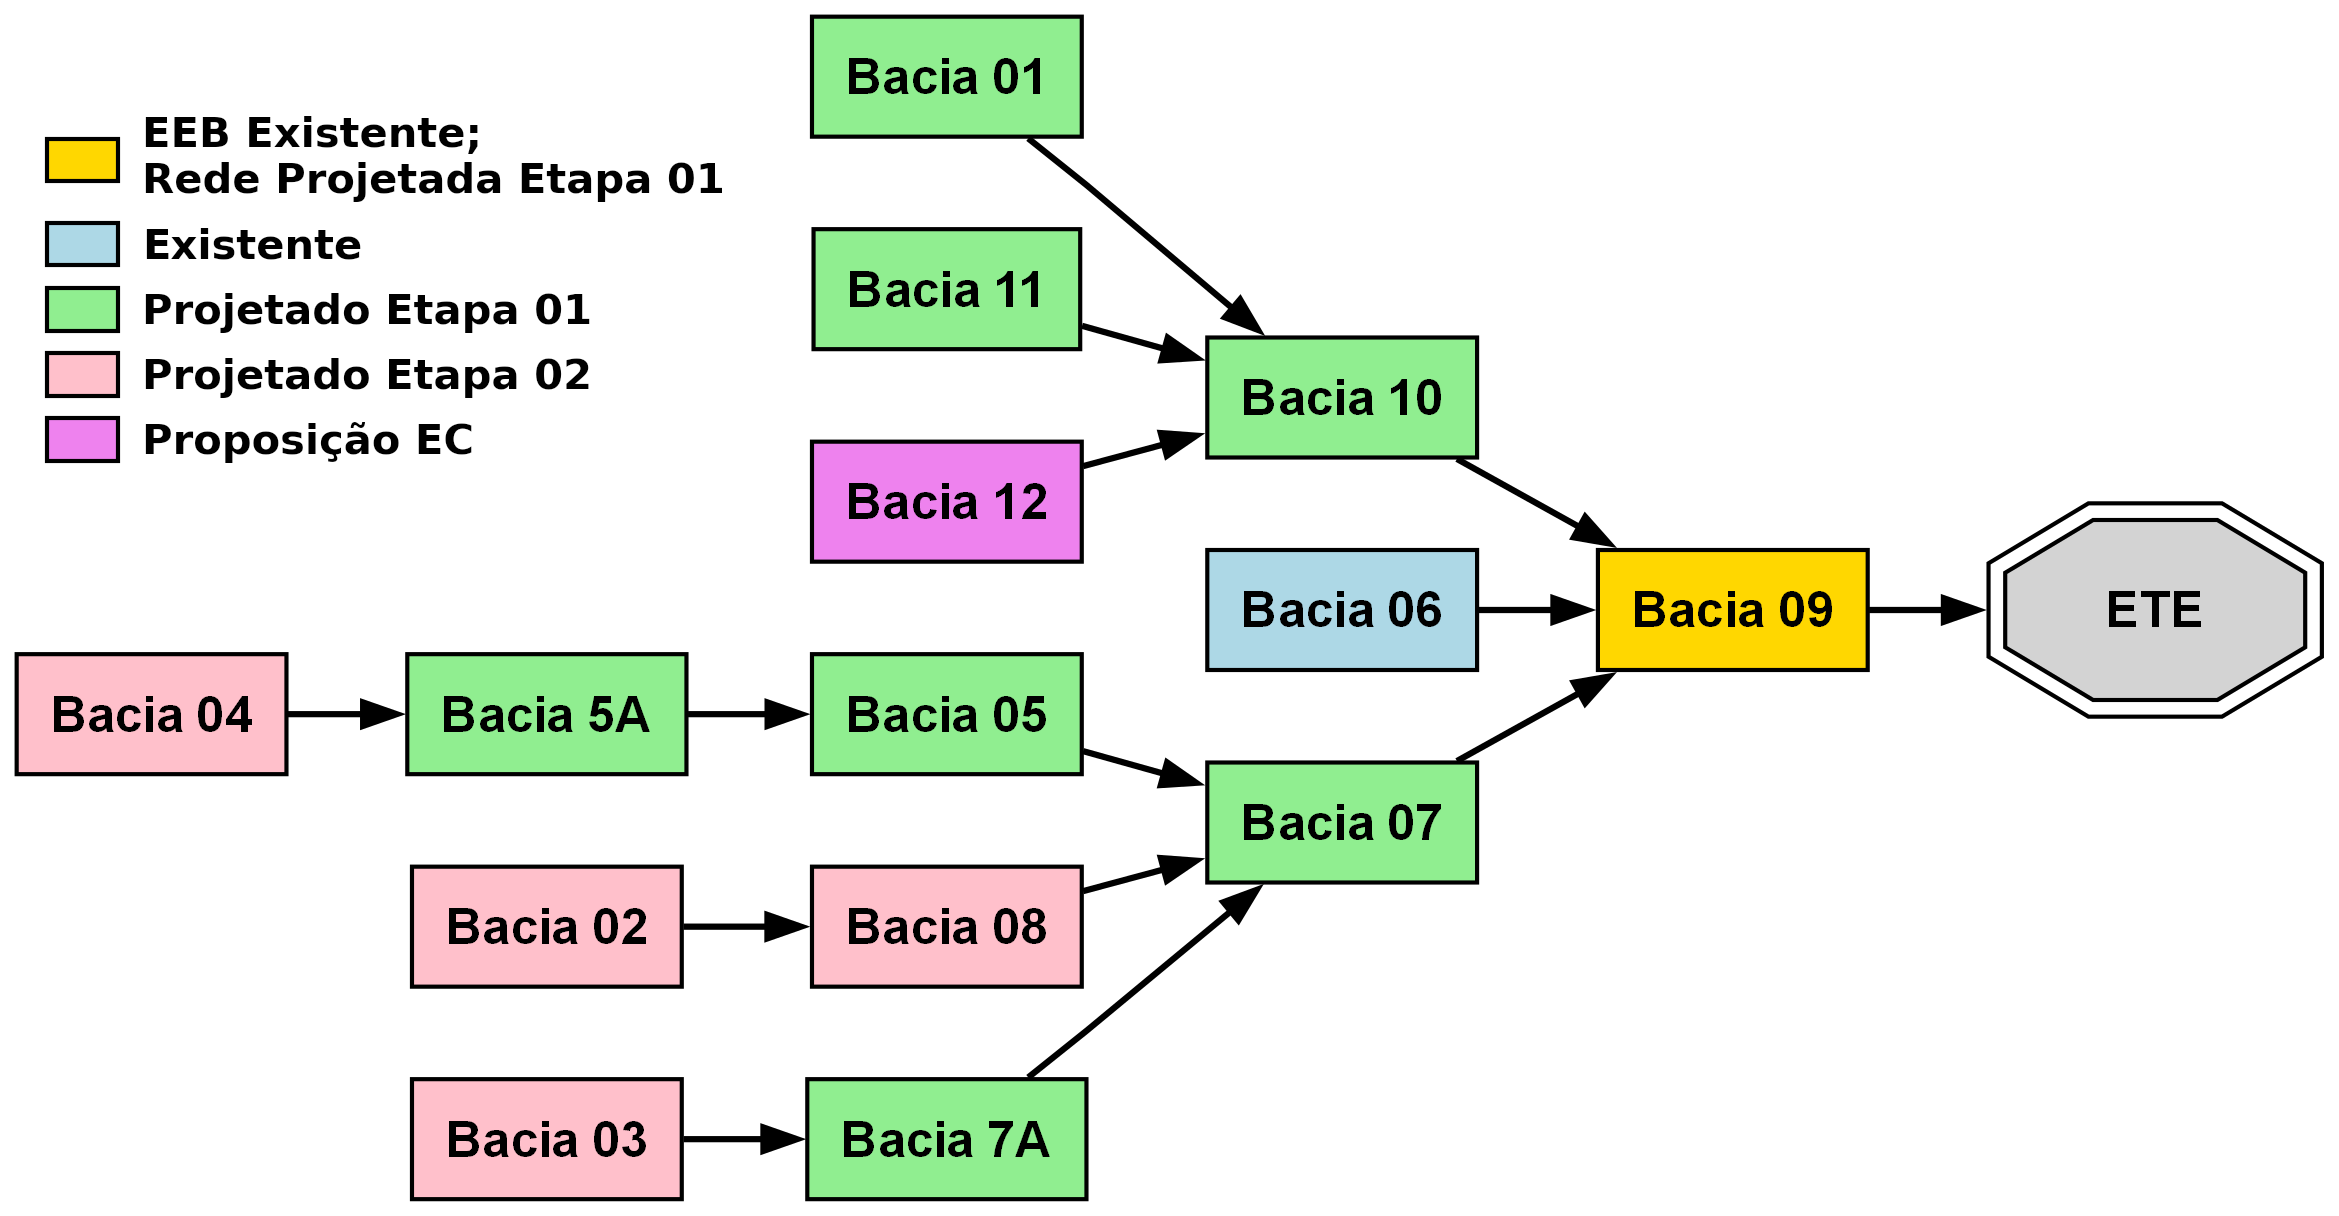

In [9]:
# Exemplo 1 (Windows com Graphviz instalado em driver local):
final = gerar_fluxograma(
    caminho_tabela=r"C:\Users\gabriel.coimbra\Desktop\Meus arquivos\Tapes\input-fluxograma-sesexistente + b12.xlsx",
    saida_dir=r"C:\Users\gabriel.coimbra\Desktop\Meus arquivos\Tapes",
    graphviz_bin_path=r"C:\Users\gabriel.coimbra\Documents\GitHub\EngSanitariaAmbiental\EC-ESGOTO_2024-25\CódigoFluxograma\drivers\Graphviz-12.2.1-win64\bin"
)

display(IPImage(final))

## Fluxograma que fiz para Manu, que tem bacia, encaminhamento, e tipo de escoamento (grav/recalque).
Talvez tenha que revisar essa função

In [ ]:
def gerar_fluxograma_simples(df, repoPath):
    """
    Gera fluxograma entre micro bacias e seus destinos, com cor de aresta
    baseada no tipo de encaminhamento e símbolo especial para ETEs.

    Argumentos:
        df (DataFrame): deve conter colunas 'MICRO BACIA', 'DESTINO', 'ENCAMINHAMENTO'.
        repoPath (str): caminho base do projeto onde será salva a imagem.
    """
    # Configura Graphviz (Windows)
    graphviz_bin_path = os.path.join(repoPath, 'drivers', 'Graphviz-12.2.1-win64', 'bin')
    os.environ["PATH"] += os.pathsep + graphviz_bin_path

    dot = Digraph(
        comment='Fluxograma Alternativa',
        format='png',
        engine='dot',
        graph_attr={
            'rankdir': 'LR',
            'splines': 'polyline',
            'size': '13.5,8.5',
            'dpi': '300',
            'fontname': 'Arial Bold',
            'fontsize': '14',
            'labelloc': 't',
            'nodesep': '0.2',
            'ranksep': '0.3'
        },
        node_attr={
            'fontname': 'Arial Bold',
            'fontsize': '11',
            'shape': 'box',
            'style': 'filled',
            'fillcolor': 'lightblue',
            'width': '0.6',
            'height': '0.3'
        },
        edge_attr={
            'fontname': 'Arial',
            'fontsize': '10',
            'arrowsize': '0.8',
            'penwidth': '1.5'
        }
    )

    for _, row in df.iterrows():
        origem = row['MICROBACIA']
        destino = str(row['DESTINO']) if pd.notna(row['DESTINO']) else 'ETE'
        tipo_encaminhamento = str(row.get('ENCAMINHAMENTO', '')).strip().upper()

        # Cor da seta
        if tipo_encaminhamento == 'GRAVIDADE':
            cor = 'blue'
        elif tipo_encaminhamento == 'RECALQUE':
            cor = 'red'
        else:
            cor = 'black'

        # Adiciona nós
        dot.node(origem)  # Sempre padrão

        if destino.upper().startswith("ETE"):
            dot.node(destino, shape="ellipse", fillcolor='lightgrey')
        elif destino.upper().startswith("INT"):
            dot.node(destino, fillcolor='lightgreen')
        else:
            dot.node(destino)  # padrão

        # Adiciona aresta
        dot.edge(origem, destino, color=cor)

    # Exporta imagem
    output_path = os.path.join(repoPath, 'outputs', 'fluxograma_alt_3.png')
    dot.render(output_path, view=False)
    print(f"Fluxograma salvo em: {output_path}")

In [ ]:
df_fluxo = pd.read_excel(r'C:\Users\gabriel.coimbra\Downloads\fluxo manu\Fluxo_Alt03.xlsx')[['MICROBACIA', 'DESTINO', 'ENCAMINHAMENTO']]

# Caminho base do projeto
repoPath = r'C:\Users\gabriel.coimbra\Documents\GitHub\EngSanitariaAmbiental\EC-ESGOTO_2024-25\GeoAnalise-FluxoElev-EC_2025'

# Executar a função
gerar_fluxograma_simples(df_fluxo, repoPath)